In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_excel("ecommerce_product_dataset.xlsx")

In [4]:
df.head()

,ProductName,Category,Price,Rating,NumReviews,StockQuantity,Discount,Sales,DateAdded
0,Headphones,Electronics,400.31,1.7,3772,20,0.08,466,2023-11-08
1,Headphones,Electronics,235.03,2.3,2919,663,0.33,1332,2023-09-26
2,Smartwatch,Electronics,417.90,1.8,1184,459,0.31,252,2023-10-18
3,Smartphone,Electronics,152.70,3.4,2047,475,0.49,1806,2023-12-03
4,Laptop,Electronics,394.74,1.8,1267,831,0.23,1508,2023-08-08


In [6]:
df.tail()

,ProductName,Category,Price,Rating,NumReviews,StockQuantity,Discount,Sales,DateAdded
995,Throw Blanket,Blankets,207.72,2.3,1973,16,0.46,325,2024-02-11
996,Fleece Blanket,Blankets,268.60,3.2,841,201,0.39,1546,2023-06-29
997,Throw Blanket,Blankets,92.74,2.8,3454,880,0.02,1295,2023-10-27
998,Weighted Blanket,Blankets,152.28,1.3,2850,752,0.34,1962,2023-10-26
999,Throw Blanket,Blankets,136.53,2.0,4055,282,0.38,1089,2024-01-25


In [7]:
df.describe()

,Price,Rating,NumReviews,StockQuantity,Discount,Sales,DateAdded
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000
mean,253.77551,3.025600,2498.753000,495.395000,0.251640,1011.037000,2023-12-08 16:06:14.400000
min,10.11000,1.000000,3.000000,0.000000,0.000000,0.000000,2023-06-12 00:00:00
25%,133.09250,2.100000,1201.750000,241.750000,0.130000,502.000000,2023-09-07 00:00:00
50%,251.31000,3.100000,2476.000000,505.000000,0.250000,998.000000,2023-12-03 12:00:00
75%,375.82750,4.000000,3797.500000,743.500000,0.380000,1540.000000,2024-03-07 00:00:00
max,499.74000,5.000000,4994.000000,993.000000,0.500000,1997.000000,2024-06-09 00:00:00
std,141.40362,1.151004,1463.241871,292.799253,0.146455,582.113466,NaN


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   ProductName    1000 non-null   object        
 1   Category       1000 non-null   object        
 2   Price          1000 non-null   float64       
 3   Rating         1000 non-null   float64       
 4   NumReviews     1000 non-null   int64         
 5   StockQuantity  1000 non-null   int64         
 6   Discount       1000 non-null   float64       
 7   Sales          1000 non-null   int64         
 8   DateAdded      1000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(3), object(2)
memory usage: 70.4+ KB


In [9]:
import numpy as np

In [11]:
df.shape

(1000, 9)

In [12]:
df.isnull().sum()

ProductName      0
Category         0
Price            0
Rating           0
NumReviews       0
StockQuantity    0
Discount         0
Sales            0
DateAdded        0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df['Month'] = df['DateAdded'].dt.month_name()
df['Quarter'] = df['DateAdded'].dt.quarter
df['Year'] = df['DateAdded'].dt.year

In [15]:
df.head()

,ProductName,Category,Price,Rating,NumReviews,StockQuantity,Discount,Sales,DateAdded,Month,Quarter,Year
0,Headphones,Electronics,400.31,1.7,3772,20,0.08,466,2023-11-08,November,4,2023
1,Headphones,Electronics,235.03,2.3,2919,663,0.33,1332,2023-09-26,September,3,2023
2,Smartwatch,Electronics,417.90,1.8,1184,459,0.31,252,2023-10-18,October,4,2023
3,Smartphone,Electronics,152.70,3.4,2047,475,0.49,1806,2023-12-03,December,4,2023
4,Laptop,Electronics,394.74,1.8,1267,831,0.23,1508,2023-08-08,August,3,2023


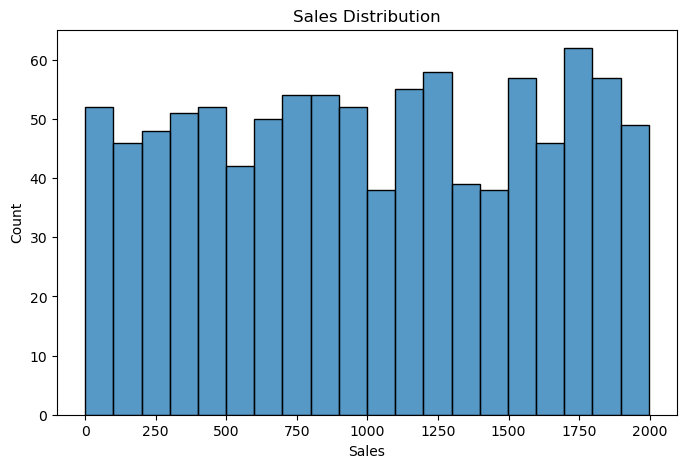

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=20)
plt.title("Sales Distribution")
plt.show()

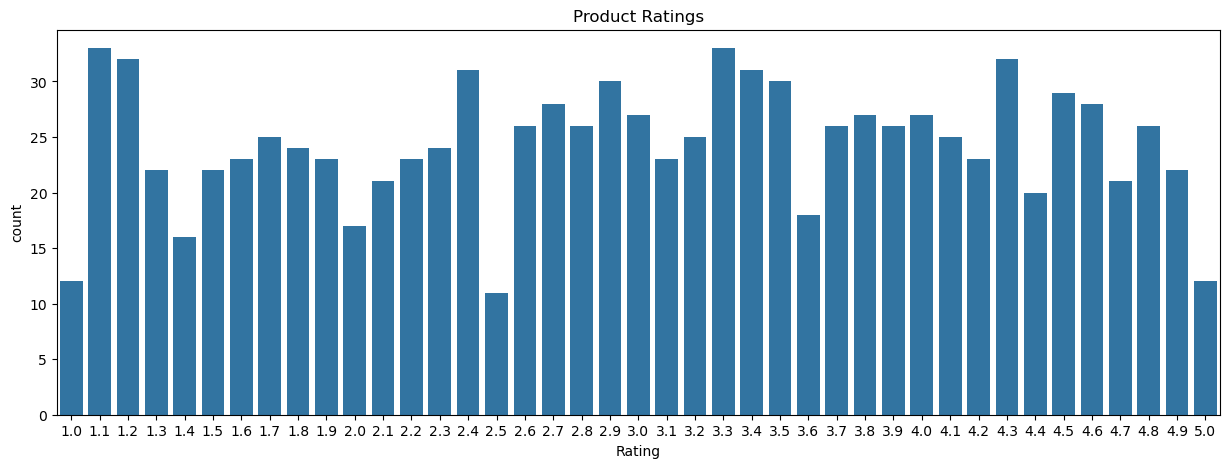

In [19]:
plt.figure(figsize=(15,5))
sns.countplot(x='Rating', data=df)
plt.title("Product Ratings")
plt.show()

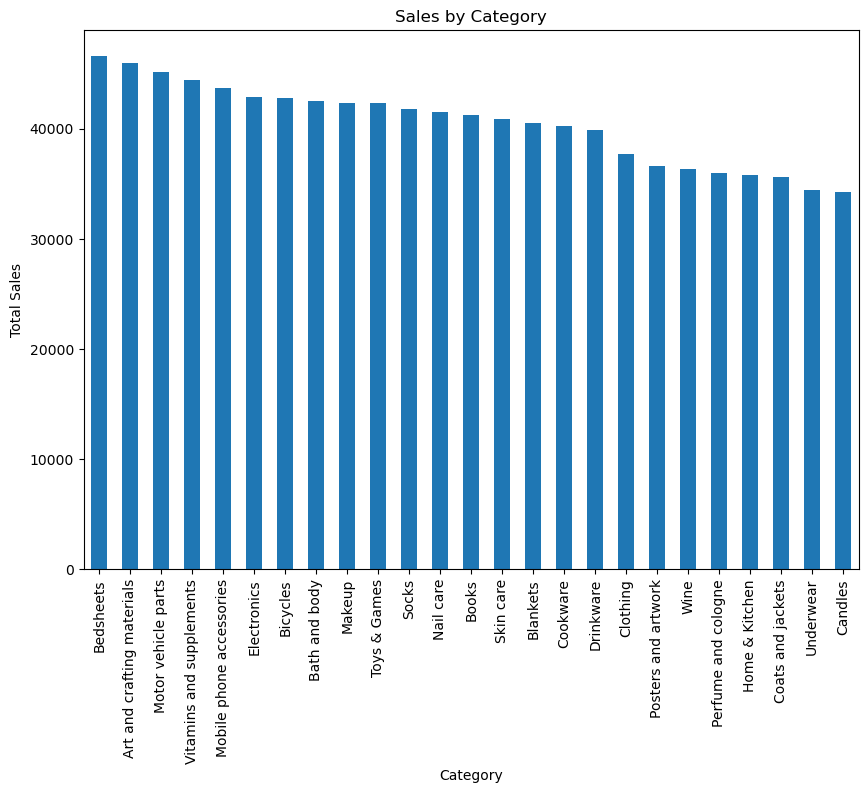

In [21]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,7))
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.ylabel("Total Sales")
plt.show()

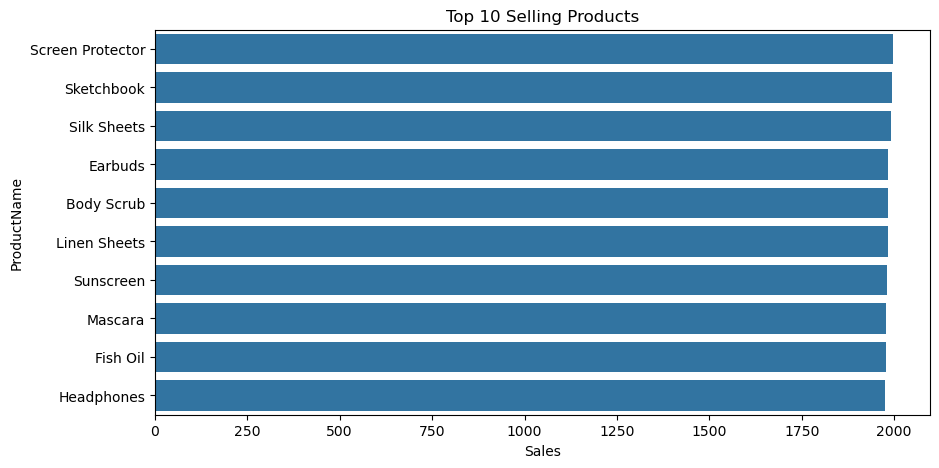

In [22]:
top_products = df.sort_values(by='Sales', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x='Sales', y='ProductName', data=top_products)
plt.title("Top 10 Selling Products")
plt.show()

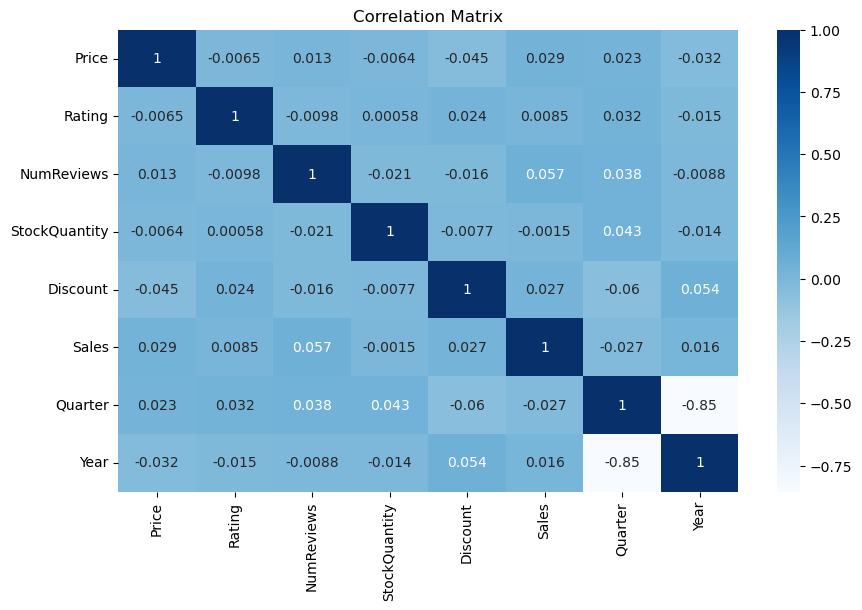

In [23]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(correlation, annot=True, cmap='Blues')
plt.title("Correlation Matrix")
plt.show()

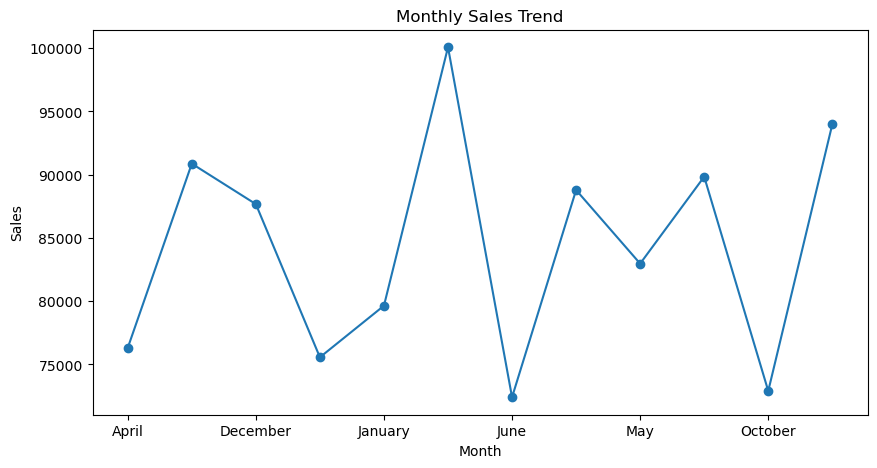

In [25]:
monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot(figsize=(10,5), marker='o')
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()

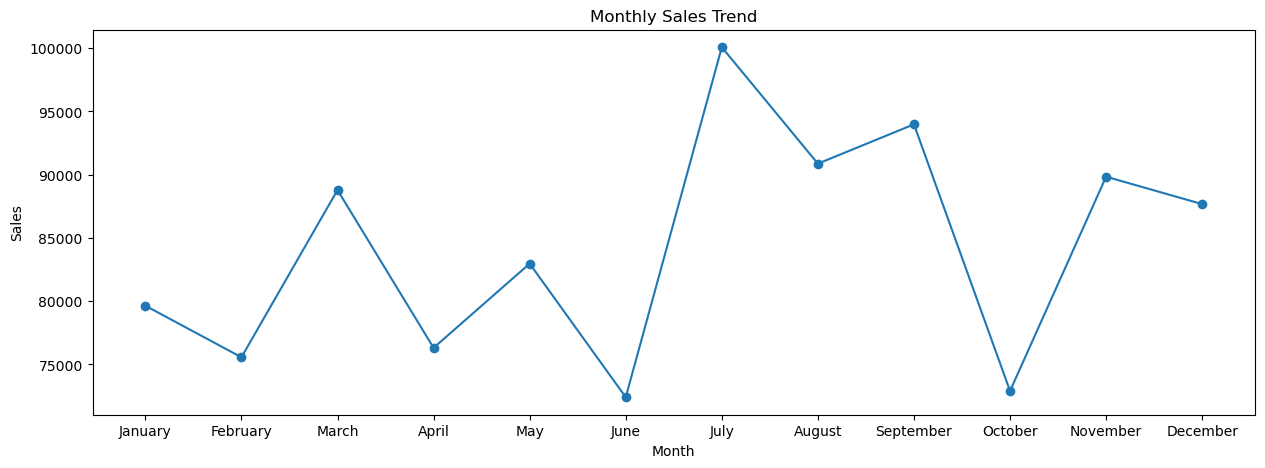

In [28]:
# Create month number
df['MonthNo'] = df['DateAdded'].dt.month

# Create month name
df['Month'] = df['DateAdded'].dt.month_name()

# Group by month number and month name
monthly_sales = df.groupby(['MonthNo', 'Month'])['Sales'].sum().reset_index()

# Sort by month number
monthly_sales = monthly_sales.sort_values('MonthNo')

# Plot
plt.figure(figsize=(15,5))
plt.plot(monthly_sales['Month'], monthly_sales['Sales'], marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

In [26]:
low_stock = df[df['StockQuantity'] < 20]

low_stock[['ProductName', 'StockQuantity']].head()

,ProductName,StockQuantity
30,Laptop,1
44,Sweater,19
56,Jeans,15
114,Blender,9
160,Board Game,16


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   ProductName    1000 non-null   object        
 1   Category       1000 non-null   object        
 2   Price          1000 non-null   float64       
 3   Rating         1000 non-null   float64       
 4   NumReviews     1000 non-null   int64         
 5   StockQuantity  1000 non-null   int64         
 6   Discount       1000 non-null   float64       
 7   Sales          1000 non-null   int64         
 8   DateAdded      1000 non-null   datetime64[ns]
 9   Month          1000 non-null   object        
 10  Quarter        1000 non-null   int32         
 11  Year           1000 non-null   int32         
 12  MonthNo        1000 non-null   int32         
dtypes: datetime64[ns](1), float64(3), int32(3), int64(3), object(3)
memory usage: 90.0+ KB


In [30]:
df.head()

,ProductName,Category,Price,Rating,NumReviews,StockQuantity,Discount,Sales,DateAdded,Month,Quarter,Year,MonthNo
0,Headphones,Electronics,400.31,1.7,3772,20,0.08,466,2023-11-08,November,4,2023,11
1,Headphones,Electronics,235.03,2.3,2919,663,0.33,1332,2023-09-26,September,3,2023,9
2,Smartwatch,Electronics,417.90,1.8,1184,459,0.31,252,2023-10-18,October,4,2023,10
3,Smartphone,Electronics,152.70,3.4,2047,475,0.49,1806,2023-12-03,December,4,2023,12
4,Laptop,Electronics,394.74,1.8,1267,831,0.23,1508,2023-08-08,August,3,2023,8


In [31]:
df.to_csv("cleaned_ecommerce_data.csv", index=False)